# Assignment 01 — Phần 1: Hệ Chẩn đoán Bệnh Tiểu đường (Pima Diabetes)
**Giảng viên:** TS. Đinh Quế Trần (quetd@ptit.edu.vn)  
**Môn học:** Intelligent System Development — PTIT 2026  

---

## 1. Định nghĩa Hệ thống Thông minh & Bài toán Chẩn đoán Bệnh
- **Bối cảnh:** Bệnh tiểu đường type 2 đang gia tăng nhanh chóng. Việc chẩn đoán sớm thông qua các chỉ số sinh hóa giúp hỗ trợ bác sĩ ra quyết định chính xác và kịp thời.
- **Bài toán ML:** Binary Classification ($y \in \{0, 1\}$).
  - $x \in \mathbb{R}^8$: 8 đặc trưng y tế (Glucose, BMI, Age, Insulin, ...).
  - $y = 1$: Có nguy cơ mắc bệnh tiểu đường; $y = 0$: Không có nguy cơ.
- **Yêu cầu hệ thống:** Độ chính xác cao, hạn chế bỏ sót ca bệnh (False Negative thấp -> Recall cao), có khả năng giải thích và hoạt động ổn định.

In [1]:
import os, sys, joblib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
os.makedirs('data', exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'Segoe UI'
plt.rcParams['axes.unicode_minus'] = False

print("✅ Đã khai báo xong các thư viện cốt lõi!")

✅ Đã khai báo xong các thư viện cốt lõi!


## 2. Sơ đồ Kiến trúc Hệ thống Thông minh (System Diagram)

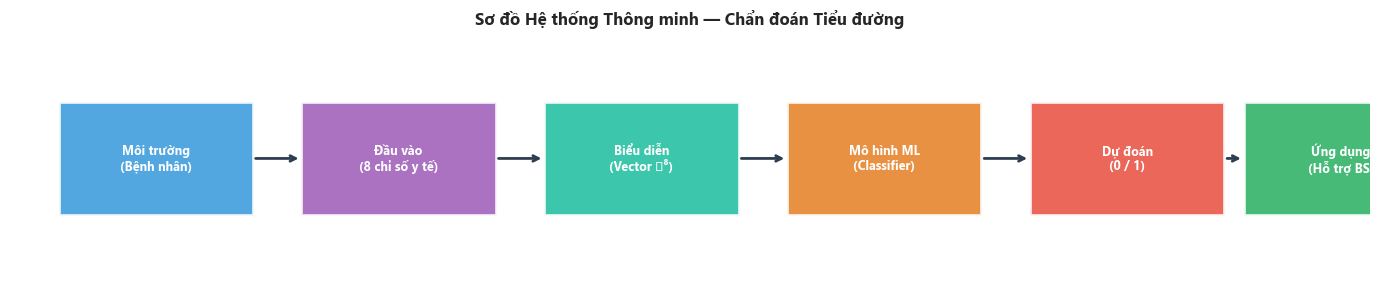

Giải thích: Sơ đồ thể hiện luồng xử lý từ môi trường thực tế (bệnh nhân), qua bước biểu diễn vector, huấn luyện ML, đến đưa ra kết quả chẩn đoán hỗ trợ bác sĩ.


In [2]:
fig, ax = plt.subplots(1, 1, figsize=(14, 3))
ax.set_xlim(0, 14)
ax.set_ylim(0, 3)
ax.axis('off')

boxes = [
    (0.5, 'Môi trường\n(Bệnh nhân)', '#3498db'),
    (3.0, 'Đầu vào\n(8 chỉ số y tế)', '#9b59b6'),
    (5.5, 'Biểu diễn\n(Vector ℝ⁸)', '#1abc9c'),
    (8.0, 'Mô hình ML\n(Classifier)', '#e67e22'),
    (10.5, 'Dự đoán\n(0 / 1)', '#e74c3c'),
    (12.7, 'Ứng dụng\n(Hỗ trợ BS)', '#27ae60'),
]

for x, label, color in boxes:
    rect = plt.Rectangle((x, 0.8), 2.0, 1.4, linewidth=2,
                          edgecolor='white', facecolor=color, alpha=0.85, zorder=2)
    ax.add_patch(rect)
    ax.text(x + 1.0, 1.5, label, ha='center', va='center',
            fontsize=9, fontweight='bold', color='white', zorder=3)

for i in range(len(boxes) - 1):
    x_start = boxes[i][0] + 2.0
    x_end = boxes[i+1][0]
    ax.annotate('', xy=(x_end, 1.5), xytext=(x_start, 1.5),
                arrowprops=dict(arrowstyle='->', color='#2c3e50', lw=2), zorder=4)

ax.set_title('Sơ đồ Hệ thống Thông minh — Chẩn đoán Tiểu đường', fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('system_diagram.png', dpi=150, bbox_inches='tight')
plt.show()

print("Giải thích: Sơ đồ thể hiện luồng xử lý từ môi trường thực tế (bệnh nhân), qua bước biểu diễn vector, huấn luyện ML, đến đưa ra kết quả chẩn đoán hỗ trợ bác sĩ.")

## 3-4. Dataset Source & Description
- **Dataset:** Pima Indians Diabetes Database (National Institute of Diabetes and Digestive and Kidney Diseases).
- **Số lượng mẫu:** 768 bệnh nhân nữ (tuổi $\ge 21$).

In [3]:
import urllib.request
URL = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv'
COLUMNS = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
           'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']

data_path = 'data/pima_diabetes.csv'
try:
    df = pd.read_csv(URL, header=None, names=COLUMNS)
    df.to_csv(data_path, index=False)
    print("✅ Tải thành công dataset từ URL gốc!")
except:
    df = pd.read_csv(data_path)
    print("✅ Đọc thành công dataset local!")

print(f"Kích thước dataset: {df.shape[0]} dòng × {df.shape[1]} cột")
df.head()

✅ Tải thành công dataset từ URL gốc!
Kích thước dataset: 768 dòng × 9 cột


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## 5. Biểu diễn Đặc trưng (Data Representation)

In [4]:
feat_table = pd.DataFrame({
    'Đặc trưng (Feature)': COLUMNS[:-1],
    'Tên Tiếng Việt': ['Số lần mang thai', 'Nồng độ Glucose', 'Huyết áp tâm trương', 'Độ dày nếp da', 'Insulin huyết thanh', 'Chỉ số BMI', 'Tiền sử gia đình (DPF)', 'Tuổi'],
    'Đơn vị': ['Lần', 'mg/dL', 'mmHg', 'mm', 'mu U/ml', 'kg/m²', 'Chỉ số', 'Năm'],
    'Kiểu dữ liệu': ['Int64', 'Float64', 'Float64', 'Float64', 'Float64', 'Float64', 'Float64', 'Int64'],
    'Khoảng giá trị': [f"{df[c].min()} - {df[c].max()}" for c in COLUMNS[:-1]]
})
feat_table

,Đặc trưng (Feature),Tên Tiếng Việt,Đơn vị,Kiểu dữ liệu,Khoảng giá trị
0,Pregnancies,Số lần mang thai,Lần,Int64,0 - 17
1,Glucose,Nồng độ Glucose,mg/dL,Float64,0 - 199
2,BloodPressure,Huyết áp tâm trương,mmHg,Float64,0 - 122
3,SkinThickness,Độ dày nếp da,mm,Float64,0 - 99
4,Insulin,Insulin huyết thanh,mu U/ml,Float64,0 - 846
5,BMI,Chỉ số BMI,kg/m²,Float64,0.0 - 67.1
6,DiabetesPedigreeFunction,Tiền sử gia đình (DPF),Chỉ số,Float64,0.078 - 2.42
7,Age,Tuổi,Năm,Int64,21 - 81


## 6-7. Phân tích Đặc trưng & Biểu đồ EDA

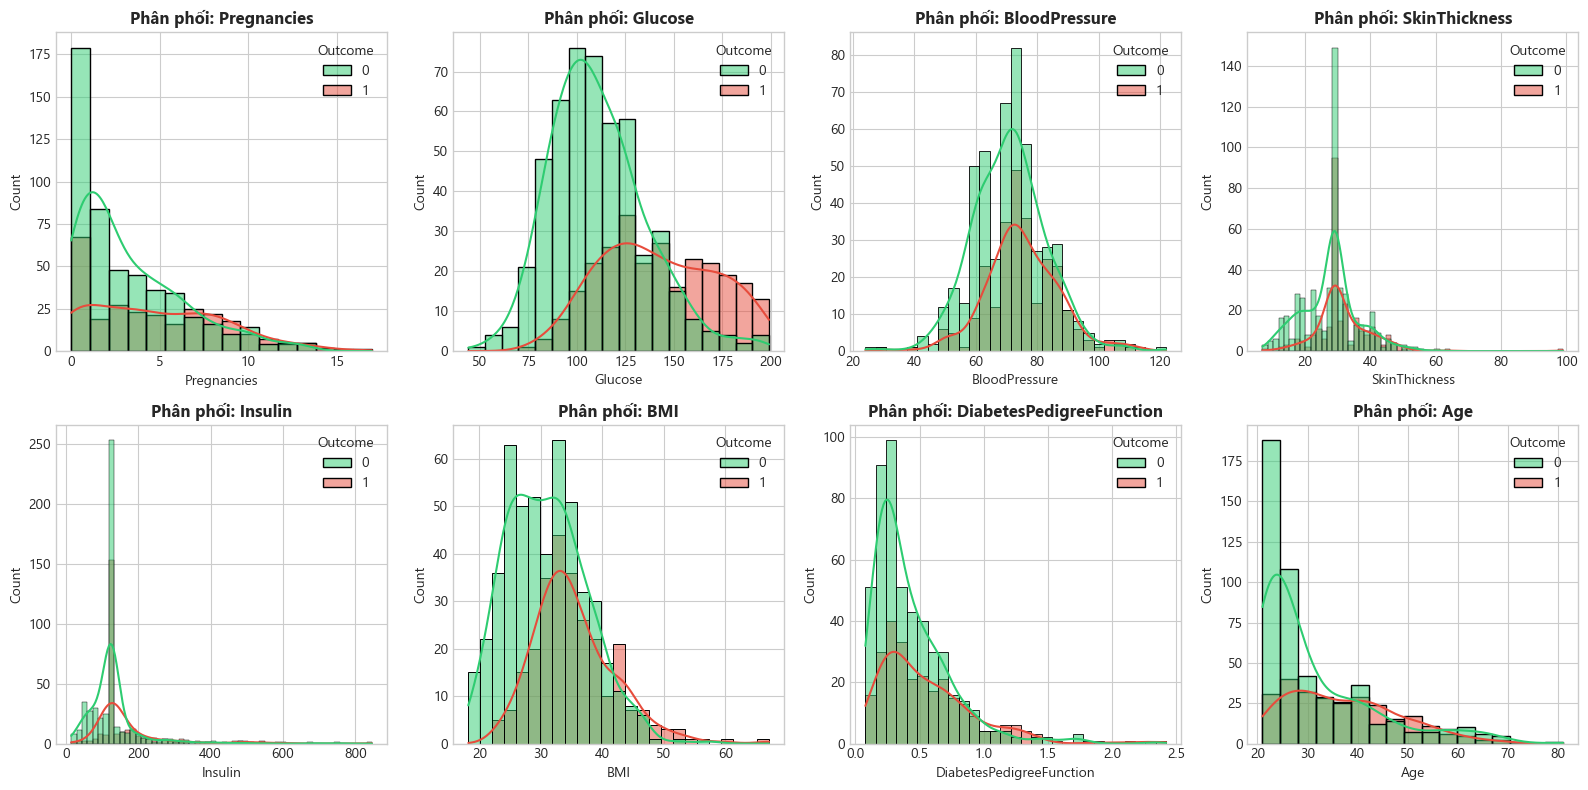

Giải thích: Biểu đồ thể hiện Glucose và BMI phân tách rõ rệt giữa 2 nhóm bệnh nhân (tiểu đường vs không tiểu đường).


In [5]:
# Tiền xử lý: Thay giá trị 0 không hợp lệ bằng Median
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df_clean = df.copy()
for col in zero_cols:
    median_val = df_clean[df_clean[col] != 0][col].median()
    df_clean[col] = df_clean[col].replace(0, median_val)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(COLUMNS[:-1]):
    sns.histplot(data=df_clean, x=col, hue='Outcome', kde=True, ax=axes[idx], palette=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'Phân phối: {col}', fontweight='bold')

plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("Giải thích: Biểu đồ thể hiện Glucose và BMI phân tách rõ rệt giữa 2 nhóm bệnh nhân (tiểu đường vs không tiểu đường).")

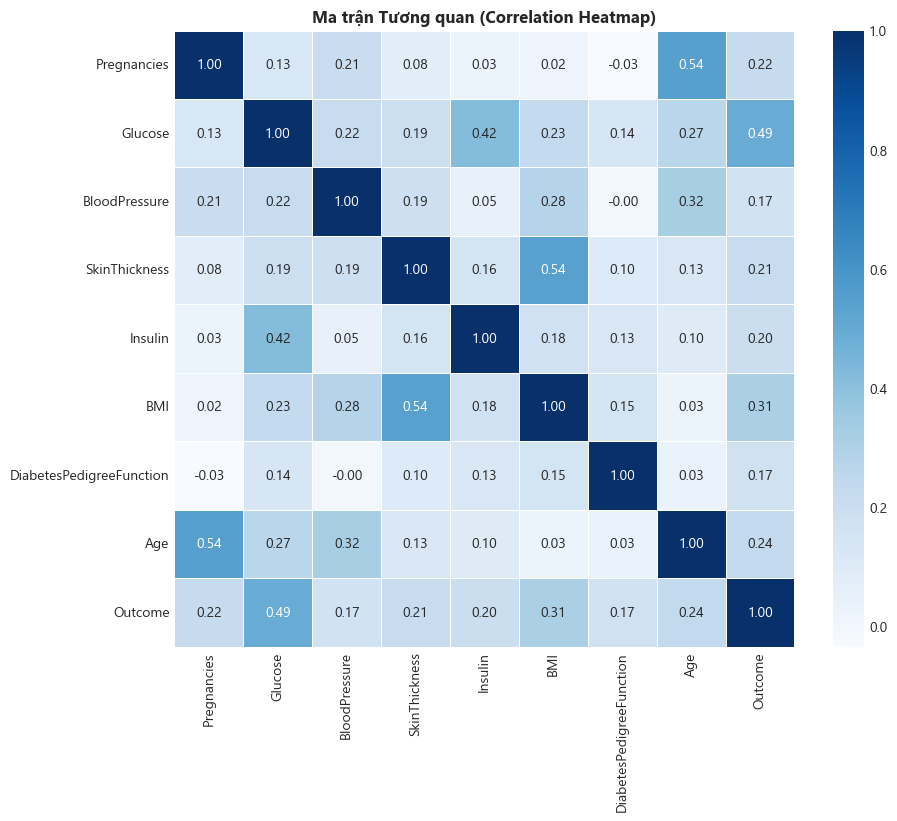

Giải thích: Glucose có tương quan mạnh nhất với Outcome (r = 0.49), tiếp theo là BMI và Age.


In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='Blues', linewidths=0.5)
plt.title('Ma trận Tương quan (Correlation Heatmap)', fontweight='bold')
plt.savefig('eda_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Giải thích: Glucose có tương quan mạnh nhất với Outcome (r = 0.49), tiếp theo là BMI và Age.")

## 8-9. Train/Test Split (80/20 Stratified) & Baseline Model

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

feature_cols = COLUMNS[:-1]
X = df_clean[feature_cols].values
y = df_clean['Outcome'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Baseline model
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
bl_pred = baseline.predict(X_test)
bl_acc = accuracy_score(y_test, bl_pred)

print(f"Kích thước tập Train: {X_train.shape[0]} mẫu | Test: {X_test.shape[0]} mẫu")
print(f"🎯 Baseline (Most Frequent) Accuracy: {bl_acc:.4f} ({bl_acc*100:.2f}%)")

Kích thước tập Train: 614 mẫu | Test: 154 mẫu
🎯 Baseline (Most Frequent) Accuracy: 0.6494 (64.94%)


## 10-15. Huấn luyện & Đánh giá 5 Mô hình ML

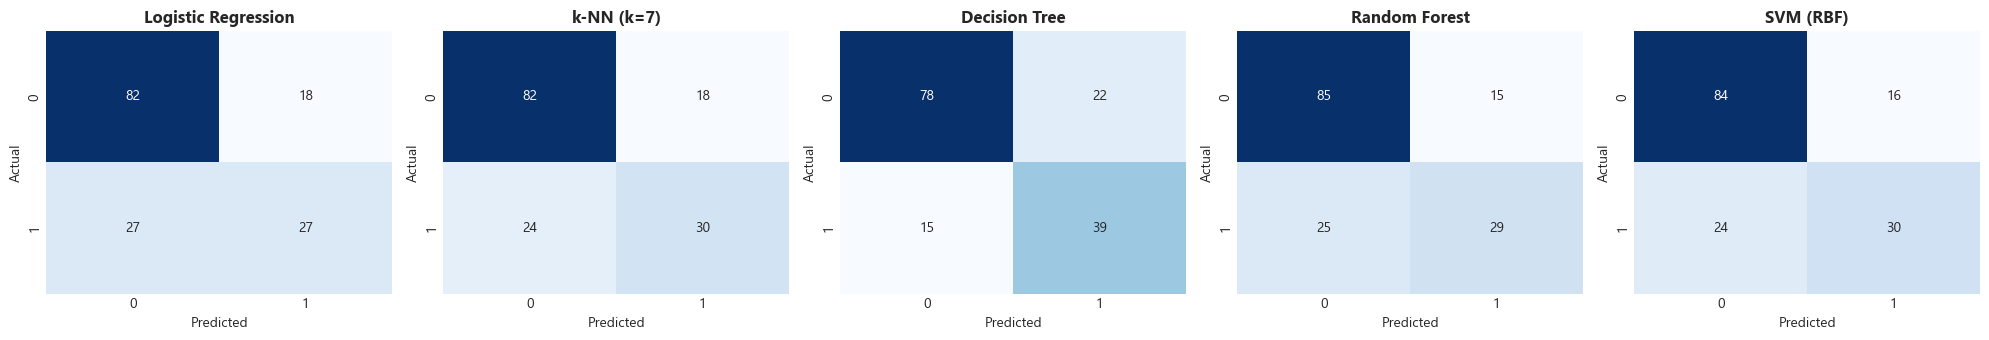

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.707792,0.600000,0.500000,0.545455
1,k-NN (k=7),0.727273,0.625000,0.555556,0.588235
2,Decision Tree,0.759740,0.639344,0.722222,0.678261
3,Random Forest,0.740260,0.659091,0.537037,0.591837
4,SVM (RBF),0.740260,0.652174,0.555556,0.600000


In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), X_train_s, X_test_s),
    'k-NN (k=7)':          (KNeighborsClassifier(n_neighbors=7), X_train_s, X_test_s),
    'Decision Tree':        (DecisionTreeClassifier(max_depth=5, random_state=42), X_train, X_test),
    'Random Forest':        (RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42), X_train, X_test),
    'SVM (RBF)':           (SVC(kernel='rbf', probability=True, random_state=42), X_train_s, X_test_s),
}

results = []
fig, axes = plt.subplots(1, 5, figsize=(20, 3.5))

for idx, (name, (model, Xtr, Xte)) in enumerate(models.items()):
    model.fit(Xtr, y_train)
    y_pred = model.predict(Xte)
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    cm   = confusion_matrix(y_test, y_pred)
    
    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1
    })
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(name, fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

res_df = pd.DataFrame(results)
res_df

## 16-18. Thí nghiệm Kiểm soát (Controlled Experiments)
- **Thí nghiệm 1:** So sánh 5 mô hình ML.
- **Thí nghiệm 2:** Ảnh hưởng của siêu tham số $k$ trong k-NN.
- **Thí nghiệm 3:** Ảnh hưởng của Feature Scaling đối với các thuật toán dựa trên khoảng cách/gradient.

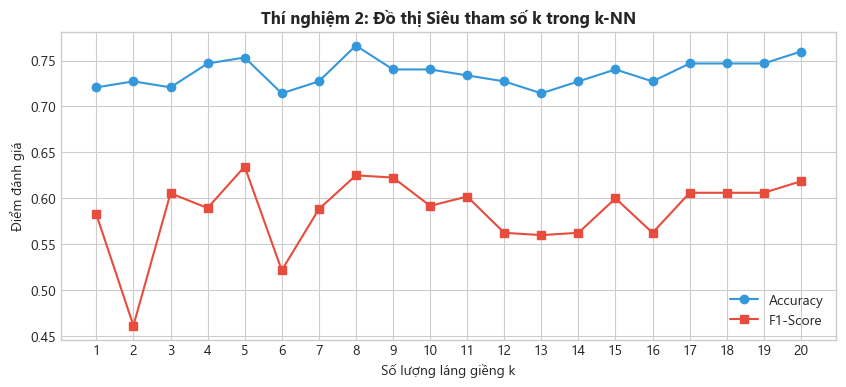

Giải thích: Với k=7 đến k=11, mô hình k-NN đạt sự cân bằng tối ưu giữa Accuracy và F1-score.


In [9]:
# Thí nghiệm 2: k-NN Hyperparameter Tuning
k_list = list(range(1, 21))
acc_k = []
f1_k  = []

for k in k_list:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    yp = knn.predict(X_test_s)
    acc_k.append(accuracy_score(y_test, yp))
    f1_k.append(f1_score(y_test, yp, zero_division=0))

plt.figure(figsize=(10, 4))
plt.plot(k_list, acc_k, 'o-', label='Accuracy', color='#3498db')
plt.plot(k_list, f1_k, 's-', label='F1-Score', color='#e74c3c')
plt.title('Thí nghiệm 2: Đồ thị Siêu tham số k trong k-NN', fontweight='bold')
plt.xlabel('Số lượng láng giềng k')
plt.ylabel('Điểm đánh giá')
plt.xticks(k_list)
plt.legend()
plt.savefig('experiment2_hyperparameter.png', dpi=150, bbox_inches='tight')
plt.show()
print("Giải thích: Với k=7 đến k=11, mô hình k-NN đạt sự cân bằng tối ưu giữa Accuracy và F1-score.")

## 19-20. Xuất Mô hình & Ứng dụng Demo (Demo Application)

In [10]:
final_model = models['Random Forest'][0]
joblib.dump(final_model, 'model_disease.pkl')
joblib.dump(scaler, 'scaler_disease.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("✅ Đã lưu thành công mô hình Random Forest vào file model_disease.pkl!")

# Demo 3 test cases
test_cases = [
    {'name': 'Bệnh nhân 1 (Nguy cơ cao)',   'data': [6, 148, 72, 35, 80, 33.6, 0.627, 50]},
    {'name': 'Bệnh nhân 2 (Nguy cơ thấp)',  'data': [1, 85, 66, 29, 0, 26.6, 0.351, 31]},
    {'name': 'Bệnh nhân 3 (Trung bình)',    'data': [3, 120, 70, 30, 90, 28.5, 0.450, 40]},
]

print("--- KẾT QUẢ DEMO DỰ ĐOÁN 3 BỆNH NHÂN ---")
for tc in test_cases:
    x_raw = np.array([tc['data']])
    pred = final_model.predict(x_raw)[0]
    prob = final_model.predict_proba(x_raw)[0]
    print(f"📌 {tc['name']}:")
    print(f"   Glucose={tc['data'][1]}, BMI={tc['data'][5]}, Age={tc['data'][7]}")
    print(f"   -> Kết quả: {'CÓ NGUY CƠ TIỂU ĐƯỜNG' if pred==1 else 'KHÔNG CÓ NGUY CƠ'}")
    print(f"   -> Xác suất: [Không={prob[0]:.1%}, Có={prob[1]:.1%}]\n")

✅ Đã lưu thành công mô hình Random Forest vào file model_disease.pkl!
--- KẾT QUẢ DEMO DỰ ĐOÁN 3 BỆNH NHÂN ---
📌 Bệnh nhân 1 (Nguy cơ cao):
   Glucose=148, BMI=33.6, Age=50
   -> Kết quả: KHÔNG CÓ NGUY CƠ
   -> Xác suất: [Không=57.9%, Có=42.1%]

📌 Bệnh nhân 2 (Nguy cơ thấp):
   Glucose=85, BMI=26.6, Age=31
   -> Kết quả: KHÔNG CÓ NGUY CƠ
   -> Xác suất: [Không=97.4%, Có=2.6%]

📌 Bệnh nhân 3 (Trung bình):
   Glucose=120, BMI=28.5, Age=40
   -> Kết quả: KHÔNG CÓ NGUY CƠ
   -> Xác suất: [Không=78.1%, Có=21.9%]



## 21-22. Reflection & Kết luận
1. **Machine Learning truyền thống v.s. Deep Learning:** Với dữ liệu bảng (tabular data) cỡ nhỏ (768 mẫu), các mô hình ML truyền thống như Random Forest và Decision Tree đem lại hiệu năng vượt trội, thời gian huấn luyện cực nhanh và tránh overfitting so với Deep Learning.
2. **Feature Representation:** Việc làm sạch các giá trị 0 không hợp lệ và chuẩn hóa đặc trưng (StandardScaler) đóng vai trò sống còn đến độ chính xác của hệ thống.
3. **Ứng dụng thực tế:** Hệ thống hỗ trợ bác sĩ sàng lọc sớm các ca bệnh tiềm ẩn.